In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mysql.connector

db = mysql.connector.connect(
    host='localhost',
    user='',
    password='',
    database='ecommerce'
)
cur = db.cursor()

  # 1. List all unique cities where customers are located.

In [29]:
query = """ select distinct customer_city from customers """  
cur.execute(query)
data = cur.fetchall()
df=pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


 #  2.Count the number of orders placed in 2017. 

In [6]:
query = """ select count(order_id)from orders where year(order_purchase_timestamp) =2017 """
cur.execute(query)
data = cur.fetchall()
"total order placed in 2017",data[0][0]

('total order placed in 2017', 90202)

 #  3.How many customers are there in each city? 

In [5]:
query = """ select customer_city,count(customer_city) as total_customers from customers  
group by customer_city  ; """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data)
df.head()


,0,1
0,franca,322
1,sao bernardo do campo,1876
2,sao paulo,31080
3,mogi das cruzes,766
4,campinas,2888


  # 4.	Count the total number of orders for each order status.

In [8]:
query = """ select order_status,count(order_id) from orders group by order_status; """
cur.execute(query)
data=cur.fetchall()
data

[('delivered', 192956),
 ('invoiced', 628),
 ('shipped', 2214),
 ('processing', 602),
 ('unavailable', 1218),
 ('canceled', 1250),
 ('created', 10),
 ('approved', 4)]

#  5.Find the top 5 cities with the highest number of customers.

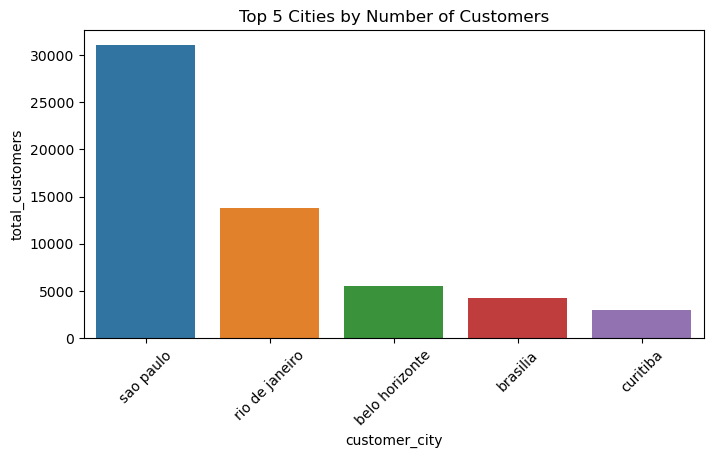

In [3]:
query = """ select customer_city, count(customer_city) as total_customers
from customers
group by customer_city
order by total_customers desc
limit 5; """
cur.execute(query)
data=cur.fetchall()
df = pd.DataFrame(data, columns=['customer_city', 'total_customers'])

plt.figure(figsize=(8,4))
sns.barplot(x='customer_city', y='total_customers', data=df, hue='customer_city', legend=False)
plt.title("Top 5 Cities by Number of Customers")
plt.xticks(rotation=45)
plt.show()

 # 6.Calculate the average payment value per order

In [5]:
query = """ select order_id, avg(payment_value)as avg_payment_per_order from payments group by order_id order by avg_payment_per_order desc
limit 5; """
cur.execute(query)
data=cur.fetchall()
data

[('03caa2c082116e1d31e67e9ae3700499', 13664.080078125),
 ('736e1922ae60d0d6a89247b851902527', 7274.8798828125),
 ('0812eb902a67711a1cb742b3cdaa65ae', 6929.31005859375),
 ('fefacc66af859508bf1a7934eab1e97f', 6922.2099609375),
 ('f5136e38d1a14a4dbd87dff67da82701', 6726.66015625)]

# 	7.Calculate the average delivery time for orders.

In [7]:
query = """ select avg(DATEDIFF(order_delivered_customer_date,
order_purchase_timestamp))
as avg_delivery_days from orders; """
cur.execute(query)
data=cur.fetchall()
"the average delivery time for orders",data[0][0]

('the average delivery time for orders', Decimal('12.4973'))

# 8.Find the top 5 cities that generated the highest revenue.

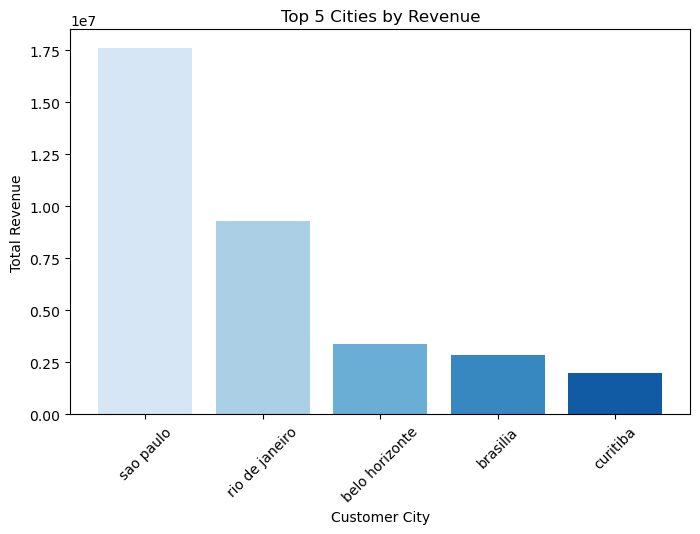

In [14]:
query = """ select c.customer_city,sum(payment_value) as total_revenue
from customers c
join orders o
ON c.customer_id=o.customer_id
join payments p
ON o.order_id=p.order_id
group by customer_city 
order by total_revenue DESC
limit 5; """
cur.execute(query)
data=cur.fetchall()

df = pd.DataFrame(data, columns=['customer_city', 'total_revenue'])

colors = sns.color_palette("Blues", len(df))
plt.figure(figsize=(8,5))
plt.bar(df['customer_city'], df['total_revenue'],color=colors)

plt.xlabel('Customer City')
plt.ylabel('Total Revenue')
plt.title('Top 5 Cities by Revenue')

plt.xticks(rotation=45)
plt.show()

# 9.Find the total number of orders placed in each city.

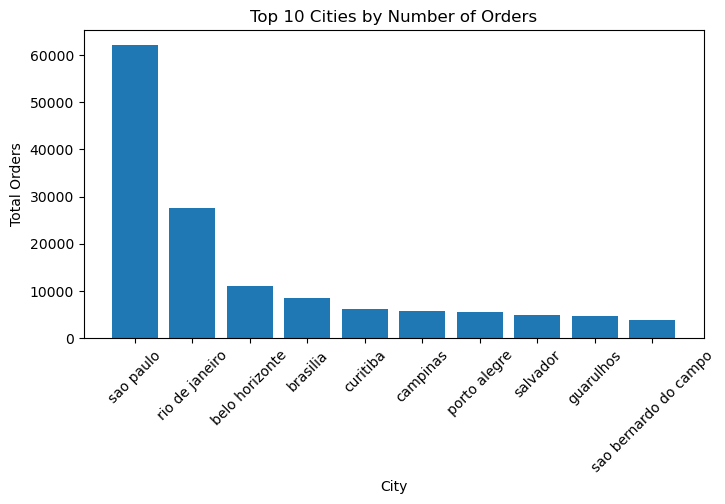

In [10]:
query=""" select c.customer_city, count(o.order_id) as total_orders
from customers c
join orders o
on c.customer_id = o.customer_id
group by c.customer_city
order by total_orders desc; """
cur.execute(query)
data=cur.fetchall()

df = pd.DataFrame(data, columns=['customer_city', 'total_orders'])
df_top = df.sort_values(by='total_orders', ascending=False).head(10)

plt.figure(figsize=(8,4))
plt.bar(df_top['customer_city'], df_top['total_orders'])
plt.xticks(rotation=45)
plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Total Orders")
plt.show()

# 10. Find all customers who have not placed any orders.

In [10]:
query = """ SELECT c.customer_id, c.customer_city  ***********************************
FROM customers c
LEFT JOIN orders o
ON c.customer_id = o.customer_id limit 5; """
cur.execute(query)
data=cur.fetchall()
data

[('6e359a57a91f84095cc64e1b351aef8c', 'sao paulo'),
 ('df0aa5b8586495e0ddf6b601122e43a1', 'sumare'),
 ('df85b96ba2ce3e49bde101b1614f52ac', 'sao jose dos pinhais'),
 ('3ccb27f9c7ee205656acef98c19fc061', 'porto alegre'),
 ('154e666b681104319714a99a3ab71e44', 'contagem')]

# 11. Calculate the percentage of orders that were paid in installments.

In [6]:
query = """ SELECT (SUM(CASE WHEN payment_installments >= 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) 
AS percentage_installments FROM payments; """
cur.execute(query)
data=cur.fetchall()
data
""" the percentage of orders that were paid in installments is """, data [0][0]

(' the percentage of orders that were paid in installments is ',
 Decimal('99.99807'))

# 12. Count the number of customers from each state. 

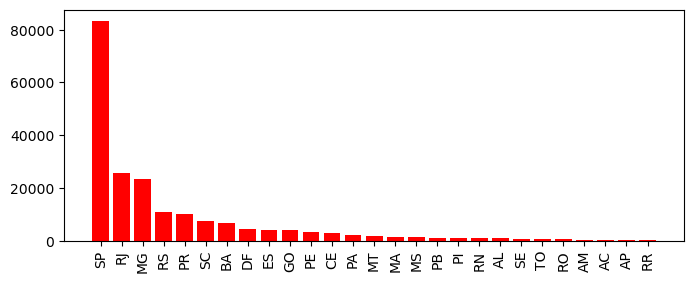

In [24]:
query = """ select customer_state,count(customer_id) from customers group by customer_state; """
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=['customer_state', 'customer_count'])
df = df.sort_values(by="customer_count", ascending=False)
plt.figure(figsize = (8,3))
plt.bar(df['customer_state'], df['customer_count'],color='red')
plt.xticks(rotation=90)
plt.show()

# 13.Calculate the number of orders per month in 2018.

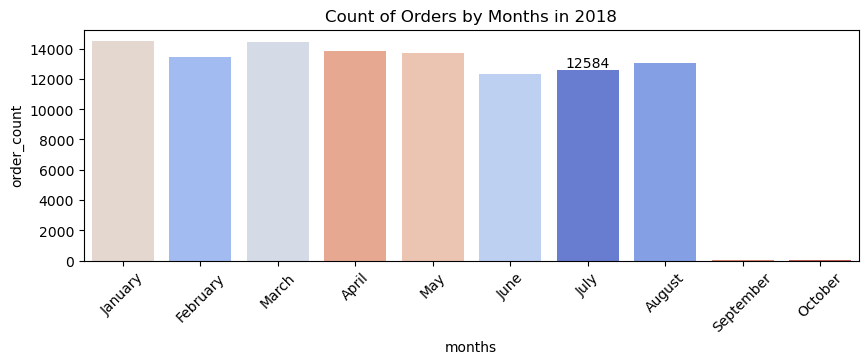

In [38]:
query = """ select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months; """
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January", "February","March","April","May","June","July","August","September","October"]

plt.figure(figsize=(10,3))
ax = sns.barplot(
    x="months",
    y="order_count",
    data=df,
    order=o,
    hue="months",   # assign hue to x variable
    dodge=False,
    palette="coolwarm",
    legend=False     # hides the extra legend
)
plt.xticks(rotation=45)
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months in 2018")
plt.show()

# 14.Find the top 10 cities with highest number of delivered orders

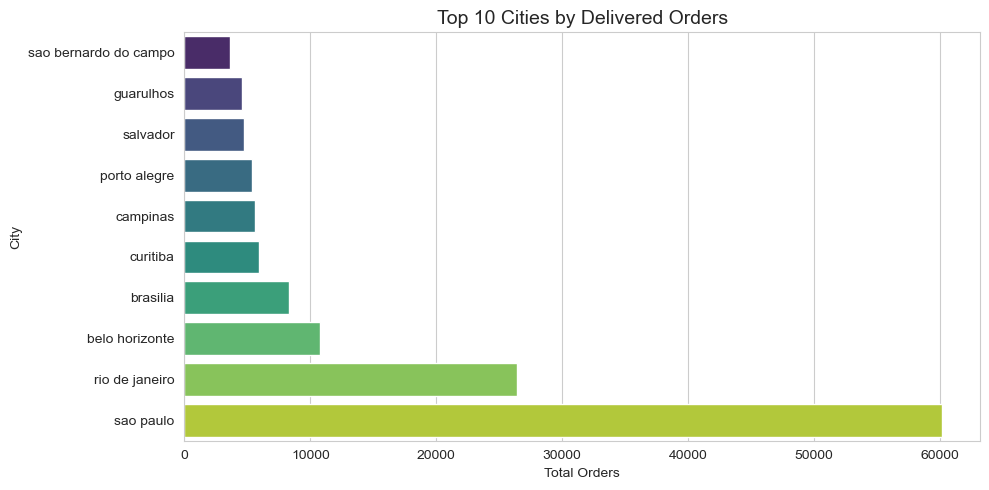

In [14]:
query = """SELECT c.customer_city, COUNT(o.order_id) AS total_orders 
FROM customers c
JOIN orders o 
ON c.customer_id = o.customer_id WHERE o.order_status = 'delivered' GROUP BY c.customer_city ORDER BY total_orders DESC LIMIT 10; """
cur.execute(query)
data=cur.fetchall()

sns.set_style("whitegrid")
plt.figure(figsize=(10,5))

sns.barplot(
    x='total_orders',
    y='customer_city',
    data=df,
    hue='customer_city',  
    palette='viridis',
    legend=False         
)
plt.title("Top 10 Cities by Delivered Orders", fontsize=14)
plt.xlabel("Total Orders")
plt.ylabel("City")
plt.tight_layout()
plt.show()